=== Cell counts (Density × Rigidity) ===
Rigidity     uniform  spread_bias_low  spread_bias_high  \
Density_Cat                                               
Sparse            56               48                53   
Dense             47               32                54   

Rigidity     concentrated_bias_low  concentrated_bias_high  \
Density_Cat                                                  
Sparse                          37                      46   
Dense                           25                      50   

Rigidity     uncertain_moderate  uncertain_strong  rigid_moderate  \
Density_Cat                                                         
Sparse                       44                47              54   
Dense                        51                48              41   

Rigidity     rigid_extreme  
Density_Cat                 
Sparse                  49  
Dense                   50  



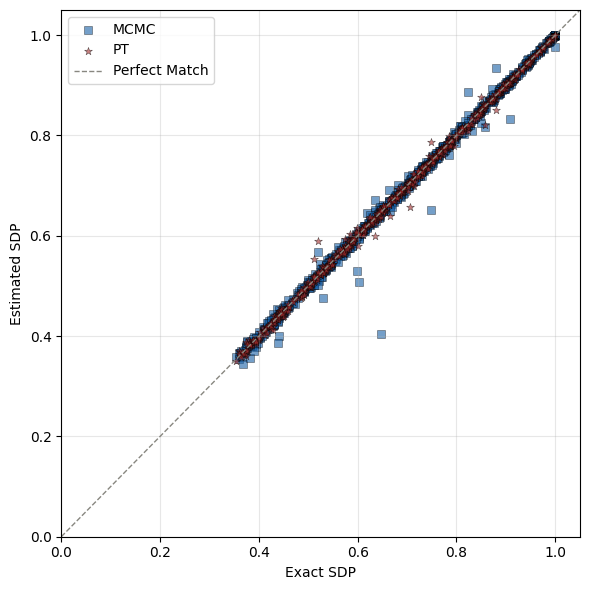

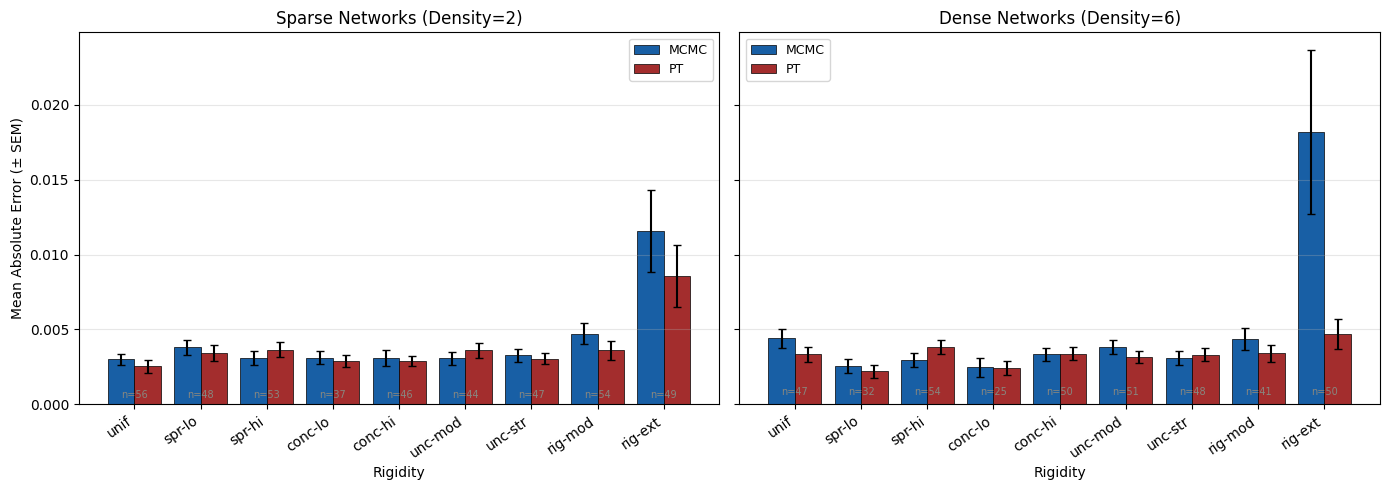

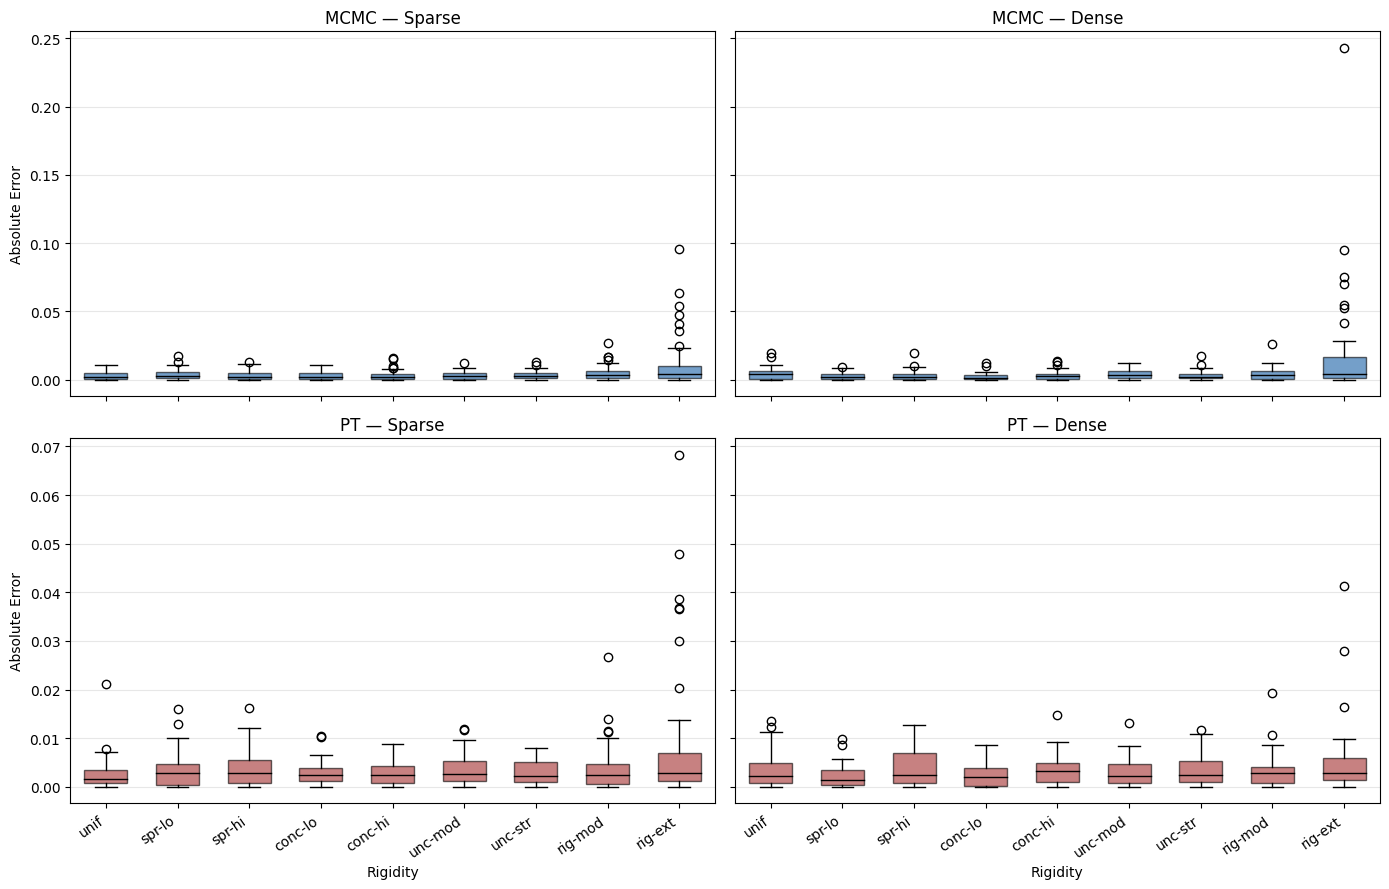

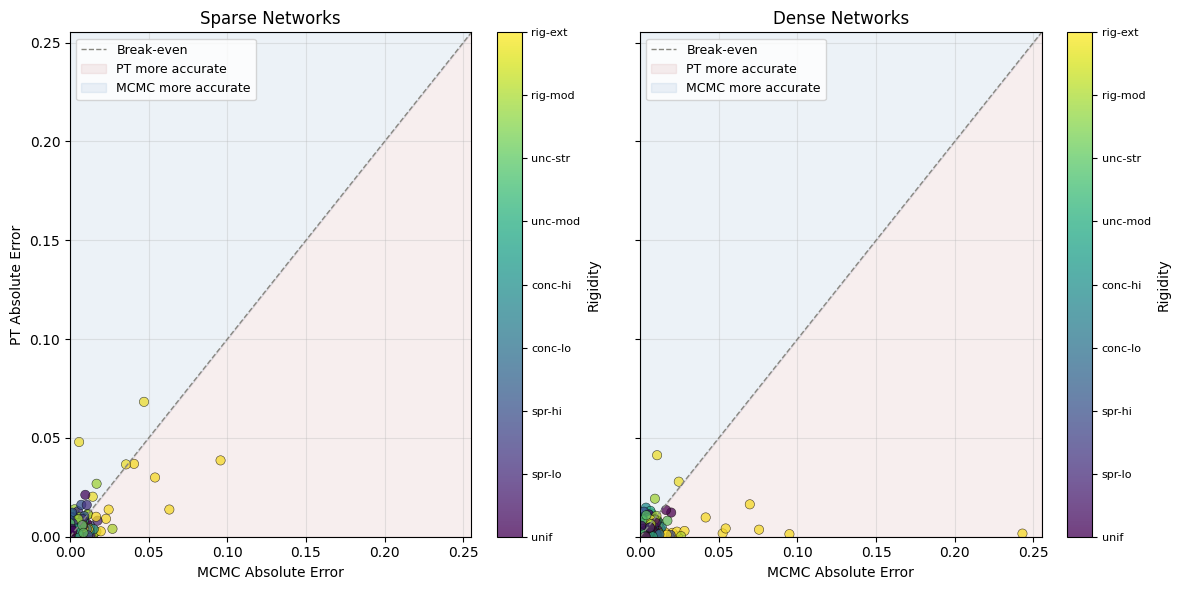

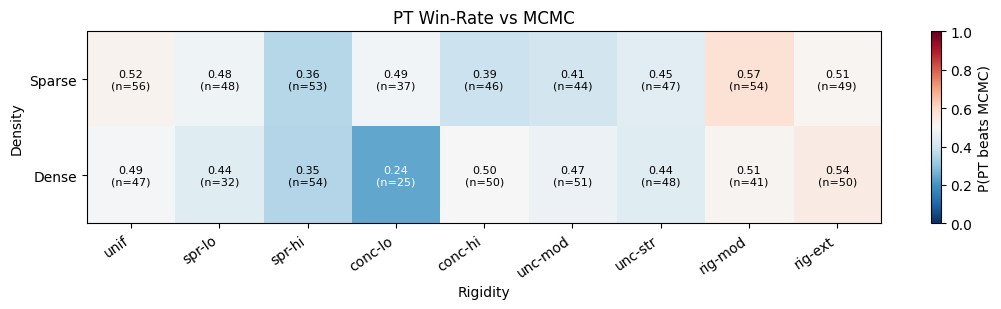

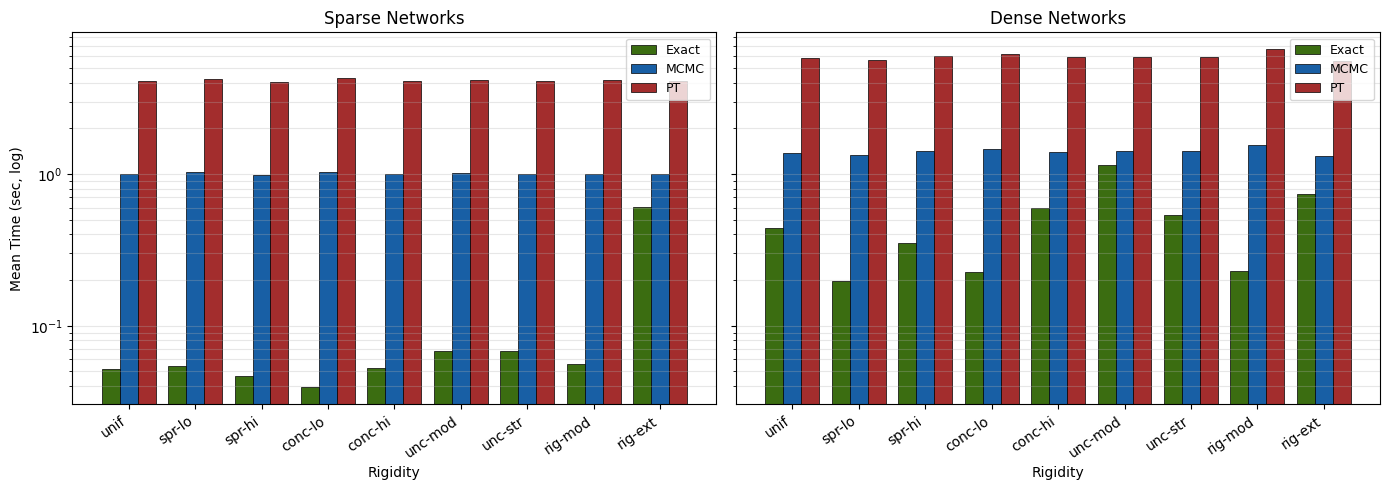


=== Summary by Density × Rigidity ===
                                     n  MCMC_mean_err  MCMC_std_err  \
Density_Cat Rigidity                                                  
Sparse      uniform                 56         0.0030        0.0028   
            spread_bias_low         48         0.0038        0.0037   
            spread_bias_high        53         0.0031        0.0034   
            concentrated_bias_low   37         0.0031        0.0028   
            concentrated_bias_high  46         0.0031        0.0036   
            uncertain_moderate      44         0.0031        0.0030   
            uncertain_strong        47         0.0033        0.0029   
            rigid_moderate          54         0.0047        0.0053   
            rigid_extreme           49         0.0116        0.0191   
Dense       uniform                 47         0.0044        0.0042   
            spread_bias_low         32         0.0026        0.0026   
            spread_bias_high        54

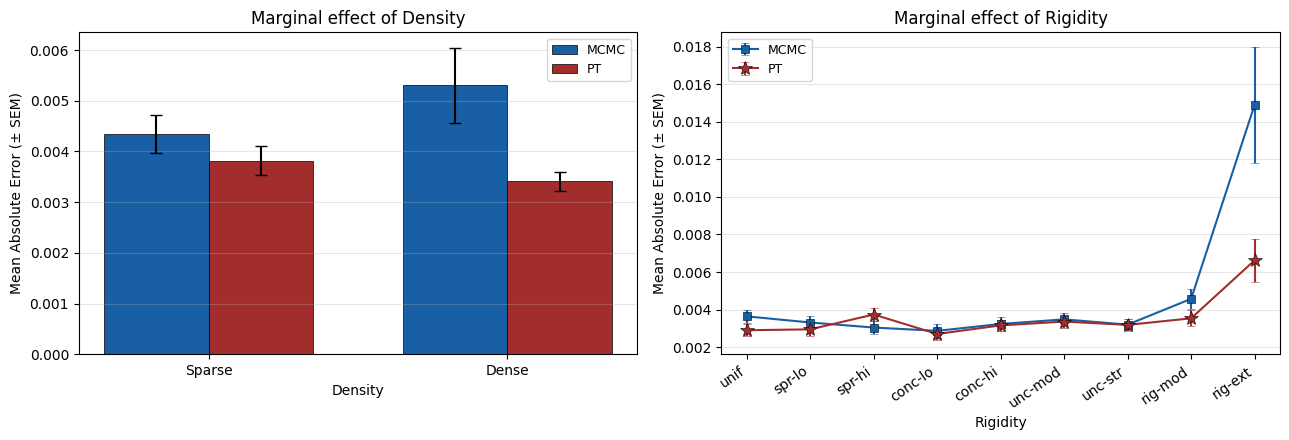

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# ============================================================
# LOAD DATA
# ============================================================
#df = pd.read_csv("targeted_sdp_synthetic_partial.csv")
df = pd.read_csv("final_results_synthetics.csv")
#df = pd.read_csv("final_results_2205974.csv")
# ============================================================
# COLORS
# ============================================================
BLUE   = '#185FA5'
RED    = '#A32D2D'
AMBER  = '#B85C00'
GREEN  = '#3B6D11'
GRAY   = '#888780'

METHOD_COLORS  = {'Exact': GREEN, 'MCMC': BLUE, 'PT': RED}
METHOD_MARKERS = {'Exact': 'o',   'MCMC': 's',  'PT': '*'}

# ============================================================
# CATEGORICAL ENCODING
# ============================================================
# Density: 2 = sparse, 6 = dense
df['Density_Cat'] = df['Density'].map({2: 'Sparse', 6: 'Dense'})

# Rigidity: 9 ordered levels, from least to most "opinionated"
RIGIDITY_ORDER = [
    'uniform',
    'spread_bias_low',
    'spread_bias_high',
    'concentrated_bias_low',
    'concentrated_bias_high',
    'uncertain_moderate',
    'uncertain_strong',
    'rigid_moderate',
    'rigid_extreme',
]
# Short labels for axis ticks (the full names are too long for x-ticks)
RIGIDITY_SHORT = {
    'uniform':                'unif',
    'spread_bias_low':        'spr-lo',
    'spread_bias_high':       'spr-hi',
    'concentrated_bias_low':  'conc-lo',
    'concentrated_bias_high': 'conc-hi',
    'uncertain_moderate':     'unc-mod',
    'uncertain_strong':       'unc-str',
    'rigid_moderate':         'rig-mod',
    'rigid_extreme':          'rig-ext',
}
df['Rigidity'] = pd.Categorical(df['Rigidity'],
                                 categories=RIGIDITY_ORDER, ordered=True)
df['Density_Cat'] = pd.Categorical(df['Density_Cat'],
                                    categories=['Sparse', 'Dense'], ordered=True)

print("=== Cell counts (Density × Rigidity) ===")
print(pd.crosstab(df['Density_Cat'], df['Rigidity']))
print()

# Convenience
short_labels = [RIGIDITY_SHORT[r] for r in RIGIDITY_ORDER]
x_pos = np.arange(len(RIGIDITY_ORDER))

# ============================================================
# 1. SANITY CHECK — Exact vs Estimated SDP
# ============================================================
fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(df['Exact_SDP'], df['MCMC_Mean_SDP'],
           color=METHOD_COLORS['MCMC'], alpha=0.6, s=35,
           marker=METHOD_MARKERS['MCMC'], label='MCMC',
           edgecolors='black', linewidths=0.4)
ax.scatter(df['Exact_SDP'], df['PT_MCMC_Mean_SDP'],
           color=METHOD_COLORS['PT'], alpha=0.6, s=35,
           marker=METHOD_MARKERS['PT'], label='PT',
           edgecolors='black', linewidths=0.4)
lims = [0, 1.05]
ax.plot(lims, lims, color=GRAY, ls='--', lw=1, label='Perfect Match')
ax.set_xlim(lims); ax.set_ylim(lims)
ax.set_xlabel('Exact SDP'); ax.set_ylabel('Estimated SDP')
ax.legend(fontsize=10); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('plot_1_exact_vs_estimated.png', dpi=300, bbox_inches='tight')
plt.show()

# ============================================================
# 2. MEAN ABSOLUTE ERROR BY RIGIDITY × DENSITY (grouped bars)
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

for ax, dens in zip(axes, ['Sparse', 'Dense']):
    sub = df[df['Density_Cat'] == dens]
    g = sub.groupby('Rigidity', observed=True).agg(
        mcmc_mean=('Absolute_Error',    'mean'),
        mcmc_sem =('Absolute_Error',    'sem'),
        pt_mean  =('PT_Absolute_Error', 'mean'),
        pt_sem   =('PT_Absolute_Error', 'sem'),
    ).reindex(RIGIDITY_ORDER)

    width = 0.4
    ax.bar(x_pos - width/2, g['mcmc_mean'], width, yerr=g['mcmc_sem'],
           capsize=3, color=METHOD_COLORS['MCMC'], label='MCMC',
           edgecolor='black', linewidth=0.5)
    ax.bar(x_pos + width/2, g['pt_mean'], width, yerr=g['pt_sem'],
           capsize=3, color=METHOD_COLORS['PT'], label='PT',
           edgecolor='black', linewidth=0.5)

    n_per_cell = sub.groupby('Rigidity', observed=True).size().reindex(RIGIDITY_ORDER, fill_value=0)
    for i, n in enumerate(n_per_cell):
        ax.text(i, ax.get_ylim()[1] * 0.02, f'n={n}', ha='center',
                va='bottom', fontsize=7, color=GRAY)

    ax.set_xticks(x_pos)
    ax.set_xticklabels(short_labels, rotation=35, ha='right')
    ax.set_xlabel('Rigidity')
    ax.set_title(f'{dens} Networks (Density={2 if dens=="Sparse" else 6})')
    ax.grid(True, alpha=0.3, axis='y')
    if dens == 'Sparse':
        ax.set_ylabel('Mean Absolute Error (± SEM)')
    ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig('plot_2_error_by_rigidity_density.png', dpi=300, bbox_inches='tight')
plt.show()

# ============================================================
# 3. ERROR DISTRIBUTION (boxplots) BY RIGIDITY × DENSITY
# ============================================================
fig, axes = plt.subplots(2, 2, figsize=(14, 9), sharey='row', sharex='col')

for col, dens in enumerate(['Sparse', 'Dense']):
    sub = df[df['Density_Cat'] == dens]

    # Build per-cell data, marking empty cells so positions stay aligned
    mcmc_data, pt_data, mcmc_pos, pt_pos = [], [], [], []
    for i, r in enumerate(RIGIDITY_ORDER):
        cell = sub[sub['Rigidity'] == r]
        if len(cell) > 0:
            mcmc_data.append(cell['Absolute_Error'].values)
            pt_data.append(cell['PT_Absolute_Error'].values)
            mcmc_pos.append(i)
            pt_pos.append(i)

    # MCMC
    if mcmc_data:
        bp = axes[0, col].boxplot(mcmc_data, positions=mcmc_pos, widths=0.6,
                                   patch_artist=True,
                                   medianprops=dict(color='black'))
        for p in bp['boxes']:
            p.set_facecolor(METHOD_COLORS['MCMC']); p.set_alpha(0.6)
    axes[0, col].set_title(f'MCMC — {dens}')
    axes[0, col].set_xlim(-0.5, len(RIGIDITY_ORDER) - 0.5)
    axes[0, col].grid(True, alpha=0.3, axis='y')

    # PT
    if pt_data:
        bp = axes[1, col].boxplot(pt_data, positions=pt_pos, widths=0.6,
                                   patch_artist=True,
                                   medianprops=dict(color='black'))
        for p in bp['boxes']:
            p.set_facecolor(METHOD_COLORS['PT']); p.set_alpha(0.6)
    axes[1, col].set_title(f'PT — {dens}')
    axes[1, col].set_xticks(x_pos)
    axes[1, col].set_xticklabels(short_labels, rotation=35, ha='right')
    axes[1, col].set_xlabel('Rigidity')
    axes[1, col].set_xlim(-0.5, len(RIGIDITY_ORDER) - 0.5)
    axes[1, col].grid(True, alpha=0.3, axis='y')

axes[0, 0].set_ylabel('Absolute Error')
axes[1, 0].set_ylabel('Absolute Error')
plt.tight_layout()
plt.savefig('plot_3_error_distribution_boxplot.png', dpi=300, bbox_inches='tight')
plt.show()

# ============================================================
# 4. PT vs MCMC HEAD-TO-HEAD — split by density
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(12, 6), sharex=True, sharey=True)

max_err = max(df['Absolute_Error'].max(), df['PT_Absolute_Error'].max())
lims2 = [0, max_err * 1.05]

# Use integer codes for the rigidity colorbar
rig_codes = df['Rigidity'].cat.codes

for ax, dens in zip(axes, ['Sparse', 'Dense']):
    sub = df[df['Density_Cat'] == dens]
    sc = ax.scatter(sub['Absolute_Error'], sub['PT_Absolute_Error'],
                    c=sub['Rigidity'].cat.codes, cmap='viridis',
                    vmin=0, vmax=len(RIGIDITY_ORDER) - 1,
                    alpha=0.75, s=45, edgecolors='black', linewidths=0.4)

    ax.plot(lims2, lims2, color=GRAY, ls='--', lw=1, label='Break-even')
    ax.fill_between(lims2, 0, lims2, color=METHOD_COLORS['PT'],   alpha=0.08,
                    label='PT more accurate')
    ax.fill_between(lims2, lims2, [lims2[1]] * 2, color=METHOD_COLORS['MCMC'],
                    alpha=0.08, label='MCMC more accurate')

    ax.set_xlim(lims2); ax.set_ylim(lims2)
    ax.set_xlabel('MCMC Absolute Error')
    ax.set_title(f'{dens} Networks')
    ax.grid(True, alpha=0.3); ax.legend(loc='upper left', fontsize=9)
    cbar = plt.colorbar(sc, ax=ax, ticks=x_pos)
    cbar.ax.set_yticklabels(short_labels, fontsize=8)
    cbar.set_label('Rigidity')

axes[0].set_ylabel('PT Absolute Error')
plt.tight_layout()
plt.savefig('plot_4_head_to_head_by_density.png', dpi=300, bbox_inches='tight')
plt.show()

# ============================================================
# 5. WIN-RATE HEATMAP — where does PT beat MCMC?
# ============================================================
df['PT_Wins'] = (df['PT_Absolute_Error'] < df['Absolute_Error']).astype(int)

win_table = df.groupby(['Density_Cat', 'Rigidity'], observed=True)['PT_Wins'] \
              .mean().unstack().reindex(columns=RIGIDITY_ORDER) \
              .reindex(['Sparse', 'Dense'])
n_table = df.groupby(['Density_Cat', 'Rigidity'], observed=True).size() \
             .unstack(fill_value=0).reindex(columns=RIGIDITY_ORDER) \
             .reindex(['Sparse', 'Dense'])

fig, ax = plt.subplots(figsize=(11, 3.2))
im = ax.imshow(win_table.values, cmap='RdBu_r', vmin=0, vmax=1, aspect='auto')

ax.set_xticks(x_pos); ax.set_xticklabels(short_labels, rotation=35, ha='right')
ax.set_yticks(range(len(win_table.index)))
ax.set_yticklabels(win_table.index)
ax.set_xlabel('Rigidity'); ax.set_ylabel('Density')

for i in range(win_table.shape[0]):
    for j in range(win_table.shape[1]):
        v = win_table.values[i, j]
        n = n_table.values[i, j]
        if pd.isna(v):
            ax.text(j, i, '—', ha='center', va='center', color='black', fontsize=10)
        else:
            color = 'white' if abs(v - 0.5) > 0.25 else 'black'
            ax.text(j, i, f'{v:.2f}\n(n={n})', ha='center', va='center',
                    color=color, fontsize=8)

cbar = plt.colorbar(im, ax=ax); cbar.set_label('P(PT beats MCMC)')
ax.set_title('PT Win-Rate vs MCMC')
plt.tight_layout()
plt.savefig('plot_5_pt_winrate.png', dpi=300, bbox_inches='tight')
plt.show()

# ============================================================
# 6. EXECUTION TIME BY RIGIDITY × DENSITY (log scale)
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

for ax, dens in zip(axes, ['Sparse', 'Dense']):
    sub = df[df['Density_Cat'] == dens]
    g = sub.groupby('Rigidity', observed=True).agg(
        exact=('Exact_Time_sec',       'mean'),
        mcmc =('MCMC_Avg_Time_sec',    'mean'),
        pt   =('PT_MCMC_Avg_Time_sec', 'mean'),
    ).reindex(RIGIDITY_ORDER)

    width = 0.27
    ax.bar(x_pos - width, g['exact'], width, color=METHOD_COLORS['Exact'],
           label='Exact', edgecolor='black', linewidth=0.5)
    ax.bar(x_pos,         g['mcmc'],  width, color=METHOD_COLORS['MCMC'],
           label='MCMC',  edgecolor='black', linewidth=0.5)
    ax.bar(x_pos + width, g['pt'],    width, color=METHOD_COLORS['PT'],
           label='PT',    edgecolor='black', linewidth=0.5)

    ax.set_yscale('log')
    ax.set_xticks(x_pos)
    ax.set_xticklabels(short_labels, rotation=35, ha='right')
    ax.set_xlabel('Rigidity')
    ax.set_title(f'{dens} Networks')
    ax.grid(True, alpha=0.3, axis='y', which='both')
    if dens == 'Sparse':
        ax.set_ylabel('Mean Time (sec, log)')
    ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig('plot_6_time_by_rigidity_density.png', dpi=300, bbox_inches='tight')
plt.show()

# ============================================================
# 7. SUMMARY TABLE
# ============================================================
summary = df.groupby(['Density_Cat', 'Rigidity'], observed=True).agg(
    n              =('Absolute_Error',       'size'),
    MCMC_mean_err  =('Absolute_Error',       'mean'),
    MCMC_std_err   =('Absolute_Error',       'std'),
    MCMC_max_err   =('Absolute_Error',       'max'),
    PT_mean_err    =('PT_Absolute_Error',    'mean'),
    PT_std_err     =('PT_Absolute_Error',    'std'),
    PT_max_err     =('PT_Absolute_Error',    'max'),
    PT_winrate     =('PT_Wins',              'mean'),
    Exact_mean_time=('Exact_Time_sec',       'mean'),
    MCMC_mean_time =('MCMC_Avg_Time_sec',    'mean'),
    PT_mean_time   =('PT_MCMC_Avg_Time_sec', 'mean'),
).round(4)

print("\n=== Summary by Density × Rigidity ===")
print(summary)
summary.to_csv('summary_density_rigidity.csv')

# ============================================================
# 8. MARGINAL EFFECTS — overall view of the two factors
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# (a) Marginal effect of density
dens_summary = df.groupby('Density_Cat', observed=True).agg(
    mcmc_mean=('Absolute_Error',    'mean'),
    mcmc_sem =('Absolute_Error',    'sem'),
    pt_mean  =('PT_Absolute_Error', 'mean'),
    pt_sem   =('PT_Absolute_Error', 'sem'),
)
xd = np.arange(len(dens_summary)); width = 0.35
axes[0].bar(xd - width/2, dens_summary['mcmc_mean'], width,
            yerr=dens_summary['mcmc_sem'], capsize=4,
            color=METHOD_COLORS['MCMC'], label='MCMC',
            edgecolor='black', linewidth=0.5)
axes[0].bar(xd + width/2, dens_summary['pt_mean'], width,
            yerr=dens_summary['pt_sem'], capsize=4,
            color=METHOD_COLORS['PT'], label='PT',
            edgecolor='black', linewidth=0.5)
axes[0].set_xticks(xd); axes[0].set_xticklabels(dens_summary.index)
axes[0].set_xlabel('Density')
axes[0].set_ylabel('Mean Absolute Error (± SEM)')
axes[0].set_title('Marginal effect of Density')
axes[0].legend(fontsize=9); axes[0].grid(True, alpha=0.3, axis='y')

# (b) Marginal effect of rigidity
rig_summary = df.groupby('Rigidity', observed=True).agg(
    mcmc_mean=('Absolute_Error',    'mean'),
    mcmc_sem =('Absolute_Error',    'sem'),
    pt_mean  =('PT_Absolute_Error', 'mean'),
    pt_sem   =('PT_Absolute_Error', 'sem'),
).reindex(RIGIDITY_ORDER)

axes[1].errorbar(x_pos, rig_summary['mcmc_mean'], yerr=rig_summary['mcmc_sem'],
                 fmt='-s', color=METHOD_COLORS['MCMC'], label='MCMC',
                 capsize=3, lw=1.5, markeredgecolor='black', markeredgewidth=0.4)
axes[1].errorbar(x_pos, rig_summary['pt_mean'], yerr=rig_summary['pt_sem'],
                 fmt='-*', color=METHOD_COLORS['PT'], label='PT',
                 capsize=3, lw=1.5, markersize=10,
                 markeredgecolor='black', markeredgewidth=0.4)
axes[1].set_xticks(x_pos)
axes[1].set_xticklabels(short_labels, rotation=35, ha='right')
axes[1].set_xlabel('Rigidity')
axes[1].set_ylabel('Mean Absolute Error (± SEM)')
axes[1].set_title('Marginal effect of Rigidity')
axes[1].legend(fontsize=9); axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('plot_8_marginal_effects.png', dpi=300, bbox_inches='tight')
plt.show()

In [2]:
df.columns

Index(['Network', 'N_Nodes', 'Density', 'Rigidity', 'Hidden_Ratio',
       'Target_Bucket', 'Target_Node', 'Target_Value', 'Exact_SDP',
       'Exact_Time_sec', 'Exact_Peak_Memory_MB_Python',
       'Exact_Peak_Memory_MB_RSS', 'MCMC_Mean_SDP', 'MCMC_Variance',
       'MCMC_Avg_Time_sec', 'MCMC_Peak_Memory_MB_Python',
       'MCMC_Peak_Memory_MB_RSS', 'Absolute_Error', 'PT_MCMC_Mean_SDP',
       'PT_MCMC_Variance', 'PT_MCMC_Avg_Time_sec', 'PT_Peak_Memory_MB_Python',
       'PT_Peak_Memory_MB_RSS', 'PT_Absolute_Error', 'Density_Cat', 'PT_Wins'],
      dtype='object')

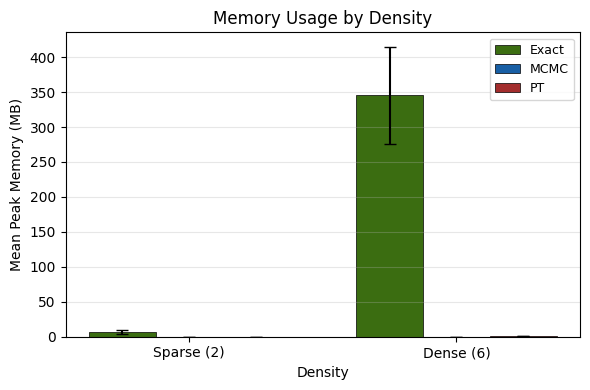

In [3]:
# how density affects memory usage (Exact_Peak_Memory_MB, MCMC_Peak_Memory_MB, PT_Peak_Memory_MB)
memory_summary = df.groupby('Density', observed=True).agg(
    exact_mem_mean=('Exact_Peak_Memory_MB_Python', 'mean'),
    exact_mem_sem =('Exact_Peak_Memory_MB_Python', 'sem'),
    mcmc_mem_mean =('MCMC_Peak_Memory_MB_Python', 'mean'),
    mcmc_mem_sem  =('MCMC_Peak_Memory_MB_Python', 'sem'),
    pt_mem_mean   =('PT_Peak_Memory_MB_Python', 'mean'),
    pt_mem_sem    =('PT_Peak_Memory_MB_Python', 'sem'),
)

# plot
fig, ax = plt.subplots(figsize=(6, 4))
xd = np.arange(len(memory_summary)); width = 0.25
ax.bar(xd - width, memory_summary['exact_mem_mean'], width,
       yerr=memory_summary['exact_mem_sem'], capsize=4,
       color=METHOD_COLORS['Exact'], label='Exact',
       edgecolor='black', linewidth=0.5)
ax.bar(xd, memory_summary['mcmc_mem_mean'], width,
       yerr=memory_summary['mcmc_mem_sem'], capsize=4,
       color=METHOD_COLORS['MCMC'], label='MCMC',
       edgecolor='black', linewidth=0.5)
ax.bar(xd + width, memory_summary['pt_mem_mean'], width,
       yerr=memory_summary['pt_mem_sem'], capsize=4,
       color=METHOD_COLORS['PT'], label='PT',
       edgecolor='black', linewidth=0.5)
ax.set_xticks(xd); ax.set_xticklabels(['Sparse (2)', 'Dense (6)'])
ax.set_xlabel('Density')
ax.set_ylabel('Mean Peak Memory (MB)')
ax.set_title('Memory Usage by Density')
ax.legend(fontsize=9); ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
#plt.savefig('memory_usage_by_density.png', dpi=300, bbox_inches='tight')
plt.show()

In [4]:
df.N_Nodes.value_counts()

20     231
50     228
100    195
200    178
Name: N_Nodes, dtype: int64

In [5]:
from bn_entropy import *
import glob
import os
from pgmpy.readwrite import BIFWriter, BIFReader

In [6]:
bif_files = sorted(glob.glob(os.path.join("/home/joao/Desktop/UFMG/PhD/code/explaining-BN/src/generated_bif_files", "*.bif")))

In [7]:
def parse_bn_filename(filename):
    base = os.path.basename(filename).replace('.bif', '').replace('bn_', '')
    parts = base.split('_')
    n_nodes = int(parts[0].replace('n', ''))
    density = int(parts[1].replace('w', ''))
    # Take every remaining part as type_CPT, joined by underscores
    type_CPT = '_'.join(parts[2:])
    return n_nodes, density, type_CPT

In [8]:
entropies = {}
for file in bif_files:
    base = os.path.basename(file)
    n, d, cpt = parse_bn_filename(file)
    if d != 12:
        print(base)
        bn = BIFReader(file).get_model()
        entropy = mean_conditional_entropy(bn)
        entropies[base] = entropy


bn_n100_w2_concentrated_bias_high.bif
bn_n100_w2_concentrated_bias_low.bif
bn_n100_w2_rigid_extreme.bif
bn_n100_w2_rigid_moderate.bif
bn_n100_w2_spread_bias_high.bif
bn_n100_w2_spread_bias_low.bif
bn_n100_w2_uncertain_moderate.bif
bn_n100_w2_uncertain_strong.bif
bn_n100_w2_uniform.bif
bn_n100_w6_concentrated_bias_high.bif
bn_n100_w6_concentrated_bias_low.bif
bn_n100_w6_rigid_extreme.bif
bn_n100_w6_rigid_moderate.bif
bn_n100_w6_spread_bias_high.bif
bn_n100_w6_spread_bias_low.bif
bn_n100_w6_uncertain_moderate.bif
bn_n100_w6_uncertain_strong.bif
bn_n100_w6_uniform.bif
bn_n200_w2_concentrated_bias_high.bif
bn_n200_w2_concentrated_bias_low.bif
bn_n200_w2_rigid_extreme.bif
bn_n200_w2_rigid_moderate.bif
bn_n200_w2_spread_bias_high.bif
bn_n200_w2_spread_bias_low.bif
bn_n200_w2_uncertain_moderate.bif
bn_n200_w2_uncertain_strong.bif
bn_n200_w2_uniform.bif
bn_n200_w6_concentrated_bias_high.bif
bn_n200_w6_concentrated_bias_low.bif
bn_n200_w6_rigid_extreme.bif
bn_n200_w6_rigid_moderate.bif
bn_n200_

In [9]:
df["Normalized_Entropy"] = df["Network"].map(entropies)

In [10]:
# save entropies to csv
entropy_df = pd.DataFrame.from_dict(entropies, orient='index', columns=['Mean_Conditional_Entropy'])
entropy_df.to_csv('synthetic_network_entropies.csv')

In [11]:
df.head()

,Network,N_Nodes,Density,Rigidity,Hidden_Ratio,Target_Bucket,Target_Node,Target_Value,Exact_SDP,Exact_Time_sec,...,Absolute_Error,PT_MCMC_Mean_SDP,PT_MCMC_Variance,PT_MCMC_Avg_Time_sec,PT_Peak_Memory_MB_Python,PT_Peak_Memory_MB_RSS,PT_Absolute_Error,Density_Cat,PT_Wins,Normalized_Entropy
0,bn_n100_w2_concentrated_bias_high.bif,100,2,concentrated_bias_high,0.25,0.4,X4,1,0.409848,0.068656,...,0.004948,0.4092,0.000244,4.324754,0.287506,0.0,0.000648,Sparse,1,0.537673
1,bn_n100_w2_concentrated_bias_high.bif,100,2,concentrated_bias_high,0.25,0.9,X4,1,0.852129,0.057055,...,0.004971,0.8458,0.000074,4.586282,0.290326,0.0,0.006329,Sparse,0,0.537673
2,bn_n100_w2_concentrated_bias_high.bif,100,2,concentrated_bias_high,0.25,1.0,X4,1,1.000000,0.062362,...,0.000000,1.0000,0.000000,4.208770,0.319975,0.0,0.000000,Sparse,0,0.537673
3,bn_n100_w2_concentrated_bias_high.bif,100,2,concentrated_bias_high,0.50,0.9,X4,1,0.944044,0.030315,...,0.000144,0.9425,0.000110,4.094356,0.289758,0.0,0.001544,Sparse,0,0.537673
4,bn_n100_w2_concentrated_bias_high.bif,100,2,concentrated_bias_high,0.50,1.0,X4,1,0.952012,0.037291,...,0.001512,0.9555,0.000021,3.800775,0.289926,0.0,0.003488,Sparse,0,0.537673


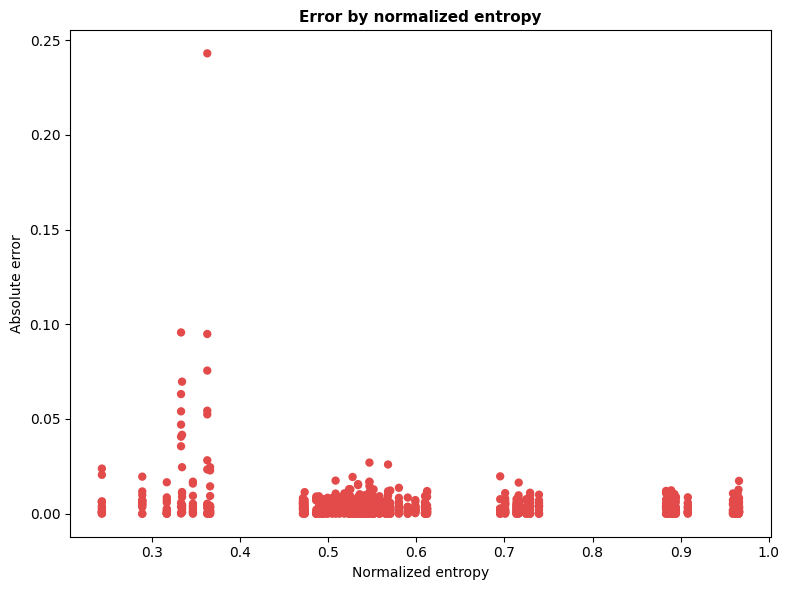

In [12]:
# Error by normalized entropy
fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(df["Normalized_Entropy"], df["Absolute_Error"], color="#E24B4A", edgecolor="none")
ax.set_title("Error by normalized entropy", fontsize=11, fontweight="bold")
ax.set_xlabel("Normalized entropy")
ax.set_ylabel("Absolute error")
plt.tight_layout()
#plt.savefig("benchmark_error_by_normalized_entropy.png", dpi=150, bbox_inches="tight")
plt.show()

Rows with entropy: 832 / 832
Entropy range: [0.243, 0.966]


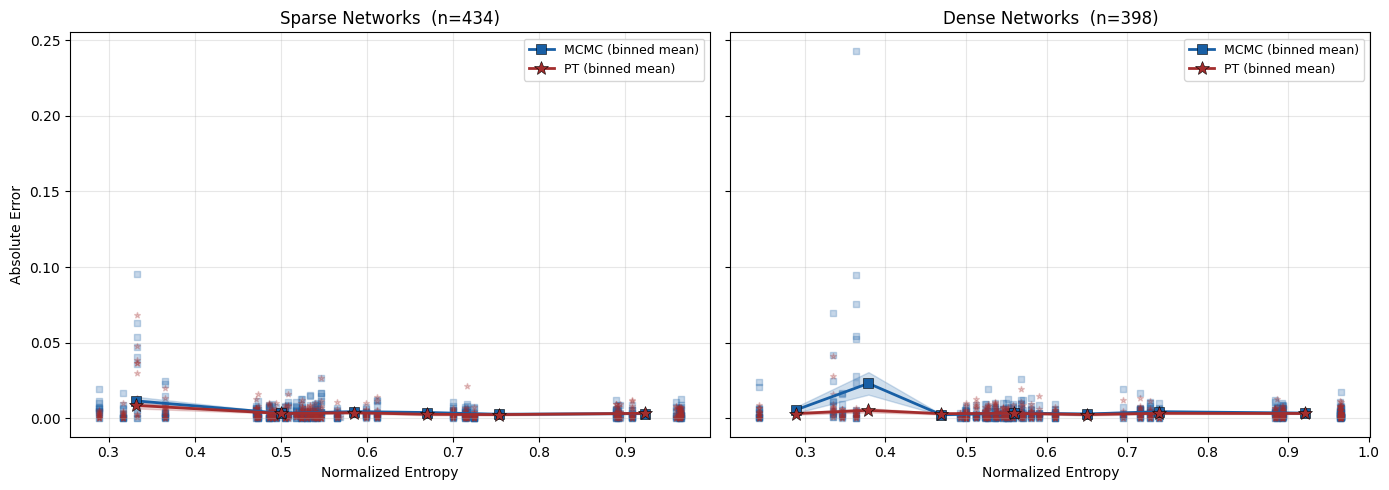


=== Correlation: Entropy vs Absolute Error ===
Subset               Method  Pearson r          p   Spearman ρ          p
---------------------------------------------------------------------------
All                  MCMC       -0.167     0.0000       -0.062     0.0737
All                  PT         -0.121     0.0005       -0.044     0.2040
Sparse               MCMC       -0.196     0.0000       -0.086     0.0728
Sparse               PT         -0.153     0.0014       -0.069     0.1529
Dense                MCMC       -0.167     0.0008       -0.029     0.5695
Dense                PT         -0.071     0.1594       -0.025     0.6154

=== OLS: Error ~ Entropy + Density + Entropy:Density ===

MCMC: R² = 0.032
  intercept       = +0.00910
  entropy         = -0.00776
  dense           = +0.00407
  entropy × dense = -0.00468

PT: R² = 0.020
  intercept       = +0.00673
  entropy         = -0.00475
  dense           = -0.00246
  entropy × dense = +0.00338


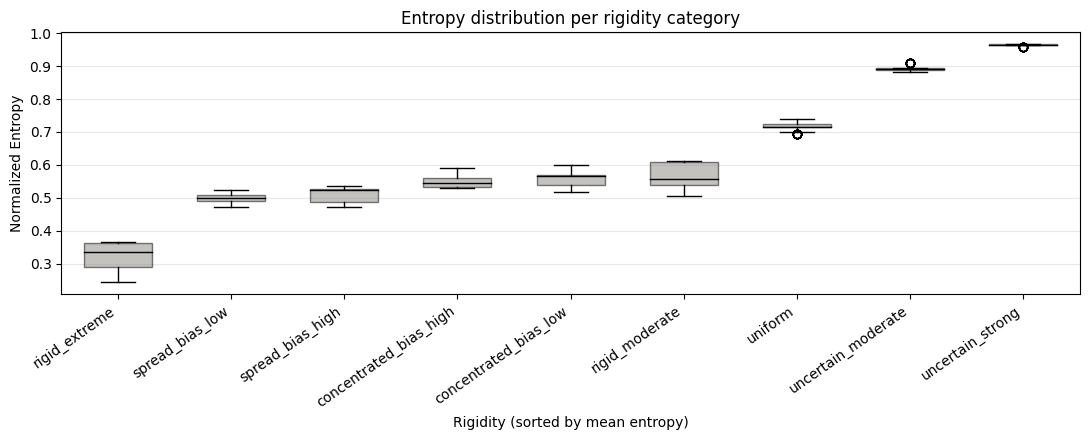

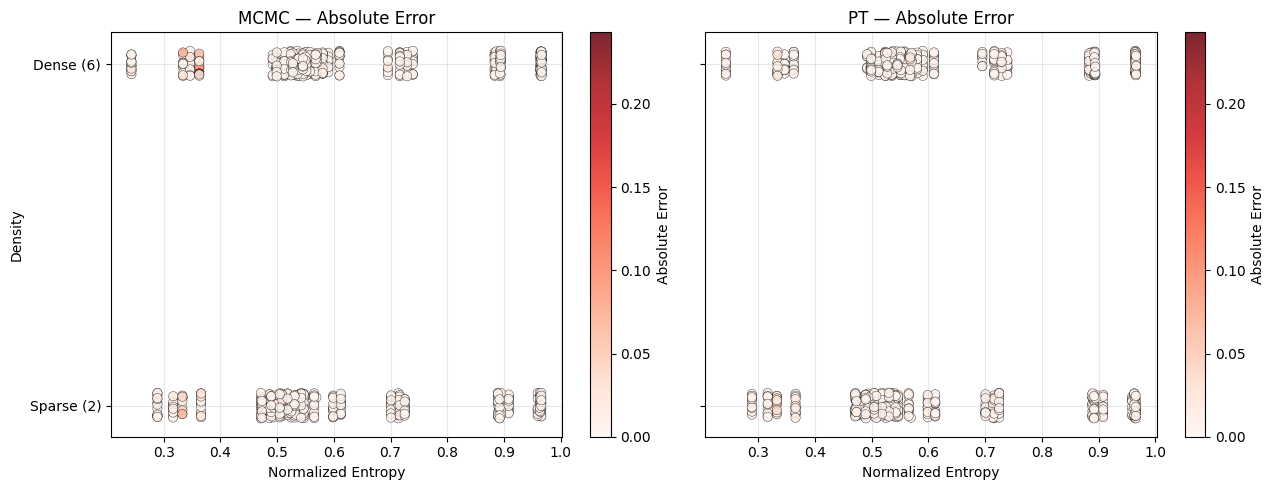

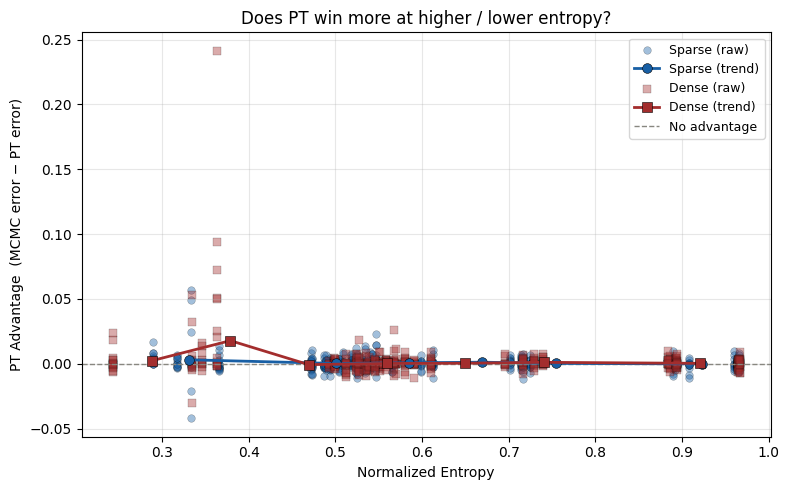


=== Per-network summary (sorted by entropy) ===
                              Network Density_Cat               Rigidity  entropy  mcmc_mean_err  pt_mean_err  n_queries
          bn_n20_w6_rigid_extreme.bif       Dense          rigid_extreme 0.243246       0.005498     0.003160         14
          bn_n20_w2_rigid_extreme.bif      Sparse          rigid_extreme 0.289065       0.006609     0.002290         13
          bn_n50_w2_rigid_extreme.bif      Sparse          rigid_extreme 0.316905       0.003772     0.002575         12
         bn_n200_w2_rigid_extreme.bif      Sparse          rigid_extreme 0.333083       0.034616     0.027734         10
         bn_n200_w6_rigid_extreme.bif       Dense          rigid_extreme 0.334206       0.015254     0.010975         12
         bn_n100_w6_rigid_extreme.bif       Dense          rigid_extreme 0.346559       0.005969     0.002502         10
          bn_n50_w6_rigid_extreme.bif       Dense          rigid_extreme 0.362840       0.042071     0.0

In [13]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import stats

# ============================================================
# ASSUMES: df already has 'Normalized_Entropy' merged in,
# 'Density_Cat' (Sparse/Dense), and 'Rigidity' as ordered categorical
# ============================================================

# Drop rows where entropy is missing (e.g. networks not in your dict)
ent_df = df.dropna(subset=['Normalized_Entropy']).copy()
print(f"Rows with entropy: {len(ent_df)} / {len(df)}")
print(f"Entropy range: [{ent_df['Normalized_Entropy'].min():.3f}, "
      f"{ent_df['Normalized_Entropy'].max():.3f}]")

# Reuse the same color scheme
BLUE='#185FA5'; RED='#A32D2D'; AMBER='#B85C00'; GREEN='#3B6D11'; GRAY='#888780'
METHOD_COLORS  = {'Exact': GREEN, 'MCMC': BLUE, 'PT': RED}
METHOD_MARKERS = {'Exact': 'o',   'MCMC': 's',  'PT': '*'}

# ============================================================
# 1. ERROR vs ENTROPY — scatter + binned trend, split by density
# ============================================================
def binned_trend(x, y, bins=8):
    """Mean ± SEM of y within bins of x. Returns (centers, means, sems)."""
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    edges = np.linspace(x.min(), x.max(), bins + 1)
    centers = 0.5 * (edges[1:] + edges[:-1])
    means, sems = [], []
    for i in range(bins):
        mask = (x >= edges[i]) & (x <= edges[i + 1])
        if mask.sum() >= 2:
            means.append(y[mask].mean())
            sems.append(y[mask].std(ddof=1) / np.sqrt(mask.sum()))
        else:
            means.append(np.nan); sems.append(np.nan)
    return np.array(centers), np.array(means), np.array(sems)

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

for ax, dens in zip(axes, ['Sparse', 'Dense']):
    sub = ent_df[ent_df['Density_Cat'] == dens]
    if len(sub) == 0:
        continue

    # Scatter raw points (small, transparent)
    ax.scatter(sub['Normalized_Entropy'], sub['Absolute_Error'],
               color=METHOD_COLORS['MCMC'], alpha=0.25, s=18,
               marker=METHOD_MARKERS['MCMC'], label='_nolegend_')
    ax.scatter(sub['Normalized_Entropy'], sub['PT_Absolute_Error'],
               color=METHOD_COLORS['PT'], alpha=0.25, s=18,
               marker=METHOD_MARKERS['PT'], label='_nolegend_')

    # Binned trend with SEM band
    n_bins = min(8, max(3, sub['Normalized_Entropy'].nunique() // 2))
    cx, cm_m, cm_s = binned_trend(sub['Normalized_Entropy'],
                                    sub['Absolute_Error'], bins=n_bins)
    cx2, cp_m, cp_s = binned_trend(sub['Normalized_Entropy'],
                                     sub['PT_Absolute_Error'], bins=n_bins)
    valid_m = ~np.isnan(cm_m); valid_p = ~np.isnan(cp_m)

    ax.plot(cx[valid_m], cm_m[valid_m], color=METHOD_COLORS['MCMC'],
            lw=2, marker='s', markersize=7, label='MCMC (binned mean)',
            markeredgecolor='black', markeredgewidth=0.4, zorder=4)
    ax.fill_between(cx[valid_m],
                    cm_m[valid_m] - cm_s[valid_m],
                    cm_m[valid_m] + cm_s[valid_m],
                    color=METHOD_COLORS['MCMC'], alpha=0.2)

    ax.plot(cx2[valid_p], cp_m[valid_p], color=METHOD_COLORS['PT'],
            lw=2, marker='*', markersize=10, label='PT (binned mean)',
            markeredgecolor='black', markeredgewidth=0.4, zorder=4)
    ax.fill_between(cx2[valid_p],
                    cp_m[valid_p] - cp_s[valid_p],
                    cp_m[valid_p] + cp_s[valid_p],
                    color=METHOD_COLORS['PT'], alpha=0.2)

    ax.set_xlabel('Normalized Entropy')
    ax.set_title(f'{dens} Networks  (n={len(sub)})')
    ax.grid(True, alpha=0.3)
    if dens == 'Sparse':
        ax.set_ylabel('Absolute Error')
    ax.legend(fontsize=9, loc='upper right')

plt.tight_layout()
plt.savefig('plot_entropy_1_error_vs_entropy.png', dpi=300, bbox_inches='tight')
plt.show()

# ============================================================
# 2. CORRELATION TESTS — Pearson & Spearman, by density
# ============================================================
print("\n=== Correlation: Entropy vs Absolute Error ===")
print(f"{'Subset':<20} {'Method':<6} {'Pearson r':>10} {'p':>10} "
      f"{'Spearman ρ':>12} {'p':>10}")
print("-" * 75)

for dens in ['All', 'Sparse', 'Dense']:
    sub = ent_df if dens == 'All' else ent_df[ent_df['Density_Cat'] == dens]
    if len(sub) < 3:
        continue
    for method, col in [('MCMC', 'Absolute_Error'), ('PT', 'PT_Absolute_Error')]:
        pr, pp = stats.pearsonr(sub['Normalized_Entropy'], sub[col])
        sr, sp = stats.spearmanr(sub['Normalized_Entropy'], sub[col])
        print(f"{dens:<20} {method:<6} {pr:>10.3f} {pp:>10.4f} "
              f"{sr:>12.3f} {sp:>10.4f}")

# ============================================================
# 3. REGRESSION — Error ~ Entropy * Density (for each method)
# ============================================================
# Encode density as 0/1 and fit error = a + b*entropy + c*density + d*entropy*density
print("\n=== OLS: Error ~ Entropy + Density + Entropy:Density ===")
ent_df['Dense_bin'] = (ent_df['Density_Cat'] == 'Dense').astype(int)

for method, col in [('MCMC', 'Absolute_Error'), ('PT', 'PT_Absolute_Error')]:
    X = np.column_stack([
        np.ones(len(ent_df)),
        ent_df['Normalized_Entropy'].values,
        ent_df['Dense_bin'].values,
        ent_df['Normalized_Entropy'].values * ent_df['Dense_bin'].values,
    ])
    y = ent_df[col].values
    coef, resid, rank, sv = np.linalg.lstsq(X, y, rcond=None)
    y_hat = X @ coef
    ss_res = np.sum((y - y_hat) ** 2)
    ss_tot = np.sum((y - y.mean()) ** 2)
    r2 = 1 - ss_res / ss_tot if ss_tot > 0 else float('nan')
    print(f"\n{method}: R² = {r2:.3f}")
    print(f"  intercept       = {coef[0]:+.5f}")
    print(f"  entropy         = {coef[1]:+.5f}")
    print(f"  dense           = {coef[2]:+.5f}")
    print(f"  entropy × dense = {coef[3]:+.5f}")

# ============================================================
# 4. WHERE DO RIGIDITY CATEGORIES LAND ON THE ENTROPY AXIS?
# ============================================================
# Sanity check: the rigidity ordering should roughly track entropy
fig, ax = plt.subplots(figsize=(11, 4.5))

# One box per rigidity level, ordered by mean entropy
ent_by_rig = ent_df.groupby('Rigidity', observed=True)['Normalized_Entropy'] \
                    .mean().sort_values()
ordered_levels = ent_by_rig.index.tolist()

box_data = [ent_df.loc[ent_df['Rigidity'] == r, 'Normalized_Entropy'].values
            for r in ordered_levels]
bp = ax.boxplot(box_data, positions=range(len(ordered_levels)),
                widths=0.6, patch_artist=True,
                medianprops=dict(color='black'))
for patch in bp['boxes']:
    patch.set_facecolor(GRAY); patch.set_alpha(0.5)

ax.set_xticks(range(len(ordered_levels)))
ax.set_xticklabels(ordered_levels, rotation=35, ha='right')
ax.set_ylabel('Normalized Entropy')
ax.set_xlabel('Rigidity (sorted by mean entropy)')
ax.set_title('Entropy distribution per rigidity category')
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig('plot_entropy_2_rigidity_mapping.png', dpi=300, bbox_inches='tight')
plt.show()

# ============================================================
# 5. 2D MAP — error magnitude across the (entropy, density) space
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True)

vmax = max(ent_df['Absolute_Error'].max(), ent_df['PT_Absolute_Error'].max())

for ax, (method, col) in zip(axes, [('MCMC', 'Absolute_Error'),
                                      ('PT', 'PT_Absolute_Error')]):
    # Jitter density slightly for visibility (it's binary 2 or 6)
    jitter = np.random.uniform(-0.15, 0.15, size=len(ent_df))
    sc = ax.scatter(ent_df['Normalized_Entropy'],
                    ent_df['Density'] + jitter,
                    c=ent_df[col], cmap='Reds', vmin=0, vmax=vmax,
                    s=45, alpha=0.85, edgecolors='black', linewidths=0.3)
    ax.set_yticks([2, 6])
    ax.set_yticklabels(['Sparse (2)', 'Dense (6)'])
    ax.set_xlabel('Normalized Entropy')
    ax.set_title(f'{method} — Absolute Error')
    ax.grid(True, alpha=0.3)
    plt.colorbar(sc, ax=ax, label='Absolute Error')

axes[0].set_ylabel('Density')
plt.tight_layout()
plt.savefig('plot_entropy_3_2d_map.png', dpi=300, bbox_inches='tight')
plt.show()

# ============================================================
# 6. PT ADVANTAGE vs ENTROPY
# ============================================================
# Does PT's improvement over MCMC scale with entropy?
ent_df['PT_Advantage'] = ent_df['Absolute_Error'] - ent_df['PT_Absolute_Error']

fig, ax = plt.subplots(figsize=(8, 5))
for dens, marker, color in [('Sparse', 'o', BLUE), ('Dense', 's', RED)]:
    sub = ent_df[ent_df['Density_Cat'] == dens]
    ax.scatter(sub['Normalized_Entropy'], sub['PT_Advantage'],
               alpha=0.4, s=30, marker=marker, color=color,
               edgecolors='black', linewidths=0.3, label=f'{dens} (raw)')
    n_bins = min(8, max(3, sub['Normalized_Entropy'].nunique() // 2))
    cx, cm, cs = binned_trend(sub['Normalized_Entropy'],
                                sub['PT_Advantage'], bins=n_bins)
    valid = ~np.isnan(cm)
    ax.plot(cx[valid], cm[valid], color=color, lw=2,
            marker=marker, markersize=7,
            markeredgecolor='black', markeredgewidth=0.4,
            label=f'{dens} (trend)', zorder=4)

ax.axhline(0, color=GRAY, ls='--', lw=1, label='No advantage')
ax.set_xlabel('Normalized Entropy')
ax.set_ylabel('PT Advantage  (MCMC error − PT error)')
ax.set_title('Does PT win more at higher / lower entropy?')
ax.grid(True, alpha=0.3)
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig('plot_entropy_4_pt_advantage.png', dpi=300, bbox_inches='tight')
plt.show()

# ============================================================
# 7. PER-NETWORK SUMMARY — collapse query reps, get one row per network
# ============================================================
# Useful because each network is sampled at multiple targets; this shows
# the "intrinsic" error rate per network alongside its entropy.
net_summary = ent_df.groupby(['Network', 'Density_Cat', 'Rigidity'],
                              observed=True).agg(
    entropy        =('Normalized_Entropy', 'first'),
    mcmc_mean_err  =('Absolute_Error',     'mean'),
    pt_mean_err    =('PT_Absolute_Error',  'mean'),
    n_queries      =('Absolute_Error',     'size'),
).reset_index().sort_values('entropy')

print("\n=== Per-network summary (sorted by entropy) ===")
print(net_summary.to_string(index=False))
net_summary.to_csv('summary_per_network_entropy.csv', index=False)